**Author:** Steve Landry Ndjock

**Version:** 1.0

**Python version:**  3.x

In [ ]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression
from sklearn.experimental import enable_iterative_imputer

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [ ]:
from pathlib import Path
import warnings

### Data Preparation

In [ ]:
from collections import Counter
from collections import defaultdict

In [ ]:
df_original = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
df = df_original.copy()

In [ ]:
def encoder_labels_categoriques(df):
    """
    Prend un DataFrame en entrée, convertit les variables catégoriques
    en nombres entiers (0, 1, 2, 3...) dans la même colonne, et retourne le DataFrame.
    """
    # 1. Copier le dataset pour éviter de modifier l'original
    df_encode = df.copy()

    # 2. Identifier les colonnes contenant du texte
    colonnes_categoriques = df_encode.select_dtypes(include=['object', 'category']).columns.tolist()

    if not colonnes_categoriques:
        print("Aucune colonne catégorique trouvée.")
        return df_encode

    # 3. Remplacer le texte par des codes numériques
    for colonne in colonnes_categoriques:
        # Convertit en type catégorie, puis récupère les codes numériques
        df_encode[colonne] = df_encode[colonne].astype('category').cat.codes

    return df_encode

In [ ]:
df = encoder_labels_categoriques(df)

In [ ]:
df.drop(columns=["PCIAT-PCIAT_Total", "sii"], inplace=True)

In [ ]:
df

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,0,5.0,0.0,3,51.00,0,46.000,50.8,26.000,73.90,...,0,50.55,71.80,0,3,16.877316,6.5,12.3225,2.006,448.0
1,2,9.0,0.0,1,62.55,0,48.000,46.0,22.000,75.00,...,0,46.00,64.00,2,0,14.035590,11.0,20.6250,2.010,334.0
2,2,10.0,1.0,0,71.00,0,56.500,75.6,25.400,65.00,...,0,38.00,54.00,2,2,16.648696,10.0,12.4500,2.009,453.0
3,3,9.0,0.0,0,71.00,2,56.000,81.6,26.000,60.00,...,2,31.00,45.00,3,0,18.292347,7.0,20.6250,2.010,577.0
4,1,18.0,1.0,2,65.00,1,55.003,77.0,26.000,68.00,...,0,41.60,61.40,1,1,17.894545,9.1,21.5525,1.040,460.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,1,7.0,1.0,1,65.15,0,46.070,49.0,22.250,58.50,...,2,38.50,55.00,1,0,16.229868,7.0,18.0750,2.000,547.7
8456,3,10.0,1.0,1,69.50,3,56.130,47.8,28.500,66.00,...,3,40.50,56.95,3,0,10.665793,5.0,13.5750,2.000,451.5
8457,3,10.0,1.0,3,70.00,3,49.560,47.2,25.635,63.50,...,3,43.75,60.75,1,2,13.509359,9.5,21.0375,2.004,528.0
8458,0,15.0,1.0,1,55.50,1,63.790,99.5,31.100,67.70,...,3,39.80,56.15,0,1,17.189894,10.5,24.4700,2.000,478.0


In [ ]:
X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

In [ ]:
X.shape

(8460, 83)

In [ ]:
np.unique(y, return_counts=True)

(array([0, 1, 2, 3]), array([6484, 1644,  326,    6]))

**I merge class 2 and 3 into a single class (class 2)**

In [ ]:
# I merge class 2 and 3 into a single class (class 2)
y = np.where(y == 3, 2, y)

### Data Partitioning

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scl = StandardScaler()
X_train = scl.fit_transform(X_train)
X_test = scl.transform(X_test)

### Balance classes

In [ ]:
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import CondensedNearestNeighbour
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb

In [ ]:
from scikitplot.metrics import plot_roc

In [ ]:
# SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 13512 samples
Distribution of classes after SMOTE : {np.int64(0): np.int64(4504), np.int64(1): np.int64(4504), np.int64(2): np.int64(4504)}


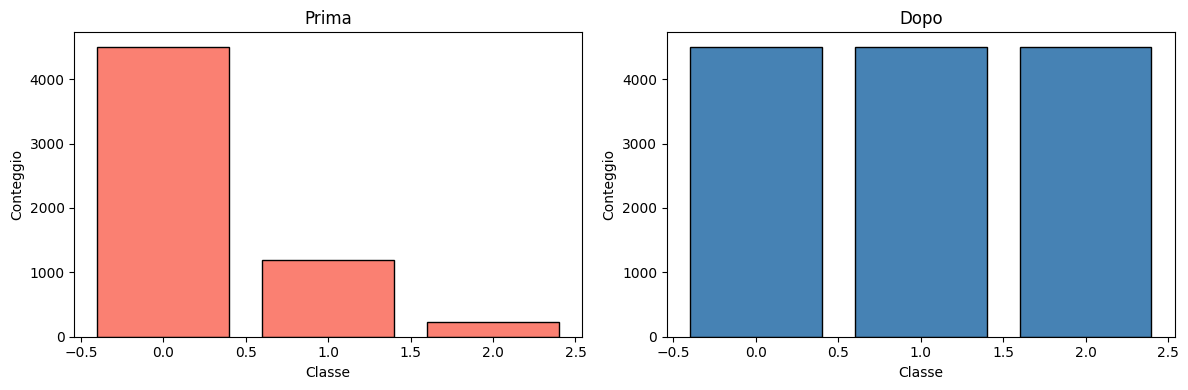

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before = Counter(y_train)
after  = Counter(y_train_resampled)

axes[0].bar(before.keys(), before.values(), color='salmon', edgecolor='black')
axes[0].set_title('Prima')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Conteggio')

axes[1].bar(after.keys(), after.values(), color='steelblue', edgecolor='black')
axes[1].set_title('Dopo')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Conteggio')

plt.tight_layout()
plt.show()

### Sklearn Multilayer Perceptron

In [ ]:
from sklearn.neural_network import MLPClassifier
hidden_layer_sizes = (100, 200,)

In [ ]:
# SelectFromModel with XGBoost
sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(13512, 13)

In [ ]:
clf = MLPClassifier(random_state=0, max_iter=500)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.942080378250591
F1-score [0.9695122  0.84411453 0.86294416]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1980
           1       0.81      0.88      0.84       453
           2       0.92      0.81      0.86       105

    accuracy                           0.94      2538
   macro avg       0.90      0.88      0.89      2538
weighted avg       0.94      0.94      0.94      2538



In [ ]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

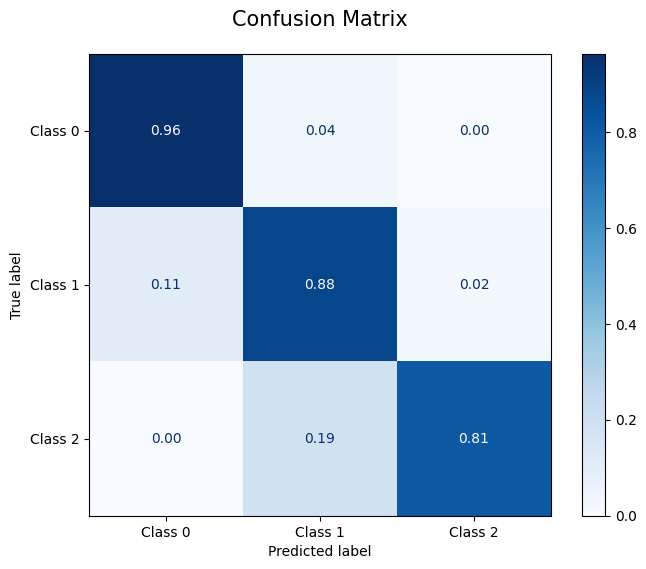

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1", "Class 2"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

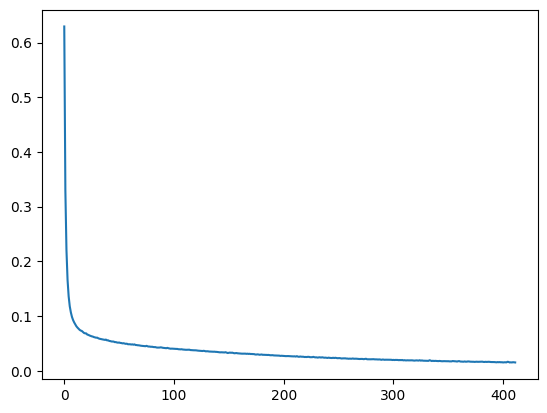

In [ ]:
plt.plot(clf.loss_curve_)
plt.show()

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(128, 64, 32,), alpha=0.1,
                    learning_rate='adaptive',
                    activation='tanh', early_stopping=False,
                    momentum=0.9, random_state=0, max_iter=500)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9412923561859732
F1-score [0.96921498 0.84749232 0.85572139]
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      1980
           1       0.79      0.91      0.85       453
           2       0.90      0.82      0.86       105

    accuracy                           0.94      2538
   macro avg       0.89      0.90      0.89      2538
weighted avg       0.95      0.94      0.94      2538



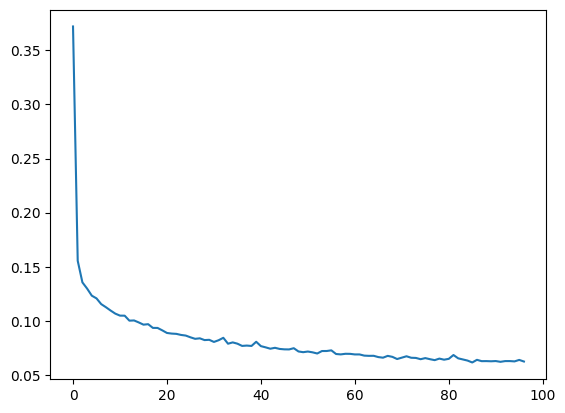

In [ ]:
plt.plot(clf.loss_curve_)
plt.show()

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(128, 64, 32,), alpha=0.1, learning_rate='adaptive',
                    activation='tanh', early_stopping=True, momentum=0.9, random_state=0)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9468085106382979
F1-score [0.97113402 0.86349848 0.88888889]
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1980
           1       0.80      0.94      0.86       453
           2       0.90      0.88      0.89       105

    accuracy                           0.95      2538
   macro avg       0.90      0.92      0.91      2538
weighted avg       0.95      0.95      0.95      2538



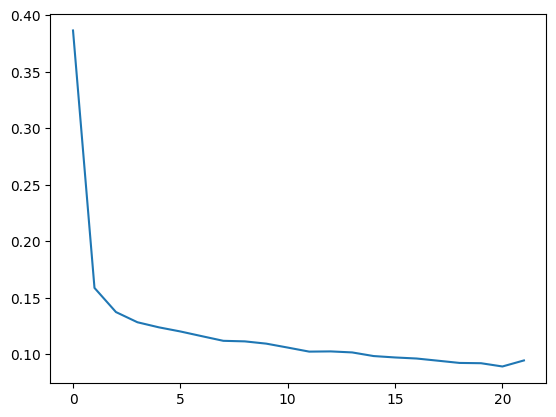

In [ ]:
plt.plot(clf.loss_curve_)
plt.show()

### New target variable data preparation

**Basic_Demos-Sex**

In [ ]:
df['sii']=df_original.loc[df.index, 'sii']
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii
0,0,5.0,0.0,3,51.00,0,46.000,50.8,26.0,73.9,...,50.55,71.8,0,3,16.877316,6.5,12.3225,2.006,448.0,2
1,2,9.0,0.0,1,62.55,0,48.000,46.0,22.0,75.0,...,46.00,64.0,2,0,14.035590,11.0,20.6250,2.010,334.0,0
2,2,10.0,1.0,0,71.00,0,56.500,75.6,25.4,65.0,...,38.00,54.0,2,2,16.648696,10.0,12.4500,2.009,453.0,0
3,3,9.0,0.0,0,71.00,2,56.000,81.6,26.0,60.0,...,31.00,45.0,3,0,18.292347,7.0,20.6250,2.010,577.0,1
4,1,18.0,1.0,2,65.00,1,55.003,77.0,26.0,68.0,...,41.60,61.4,1,1,17.894545,9.1,21.5525,1.040,460.0,1


In [ ]:
df_NN = df.copy()

In [ ]:
df.drop(columns=['Basic_Demos-Sex'], inplace=True)

In [ ]:
X = df.values
y = np.array(df_NN['Basic_Demos-Sex'])

In [ ]:
print("Distribuzione classi:", Counter(y))

Distribuzione classi: Counter({0.0: 5056, 1.0: 3404})


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 7078 samples
Distribution of classes after SMOTE : {0.0: 3539, 1.0: 3539}


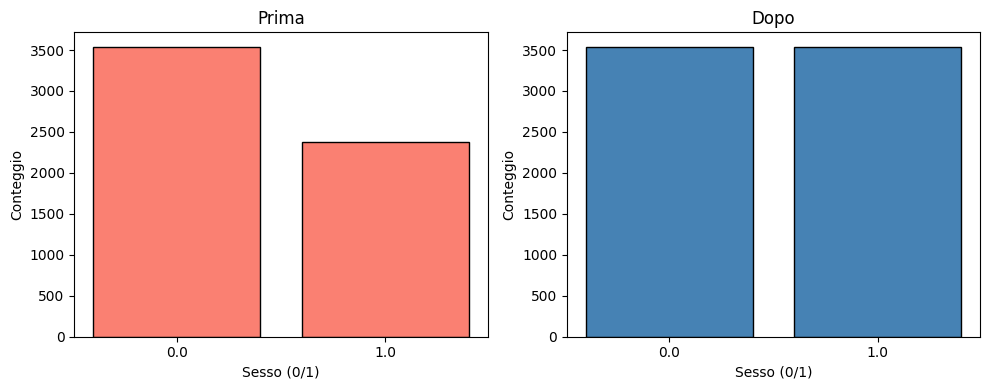

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

before = Counter(y_train)
after  = Counter(y_train_resampled)

axes[0].bar([str(k) for k in before.keys()], before.values(), color='salmon', edgecolor='black')
axes[0].set_title('Prima')
axes[0].set_xlabel('Sesso (0/1)')
axes[0].set_ylabel('Conteggio')

axes[1].bar([str(k) for k in after.keys()], after.values(), color='steelblue', edgecolor='black')
axes[1].set_title('Dopo')
axes[1].set_xlabel('Sesso (0/1)')
axes[1].set_ylabel('Conteggio')

plt.tight_layout()
plt.show()

In [ ]:
# SelectFromModel with XGBoost
sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(7078, 24)

In [ ]:
clf = MLPClassifier(random_state=0, max_iter=1000)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6985815602836879
F1-score [0.74559361 0.63025616]
              precision    recall  f1-score   support

         0.0       0.75      0.74      0.75      1517
         1.0       0.62      0.64      0.63      1021

    accuracy                           0.70      2538
   macro avg       0.69      0.69      0.69      2538
weighted avg       0.70      0.70      0.70      2538



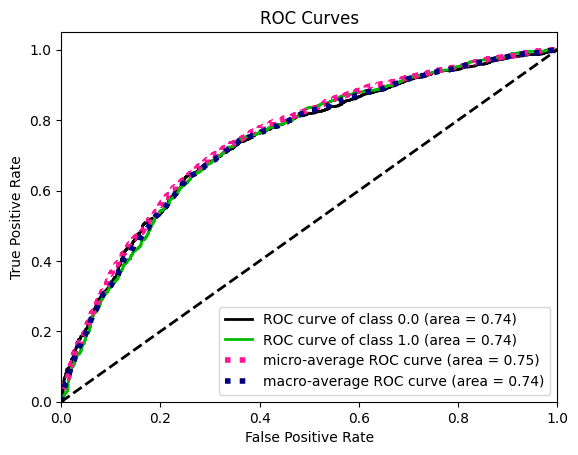

In [ ]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

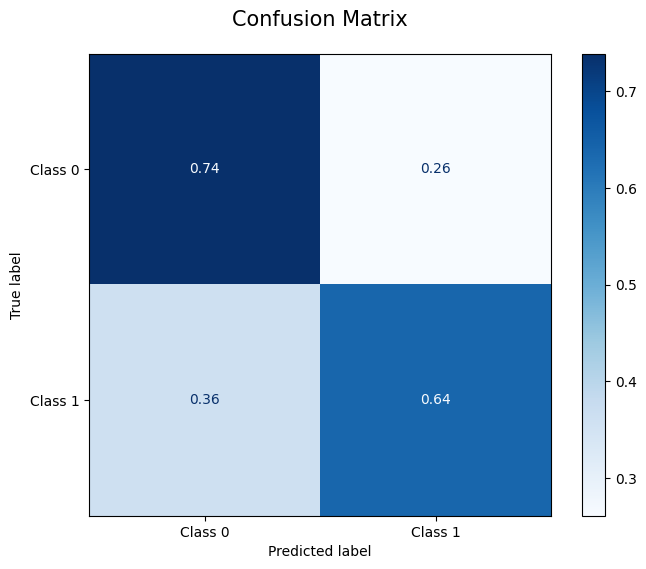

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

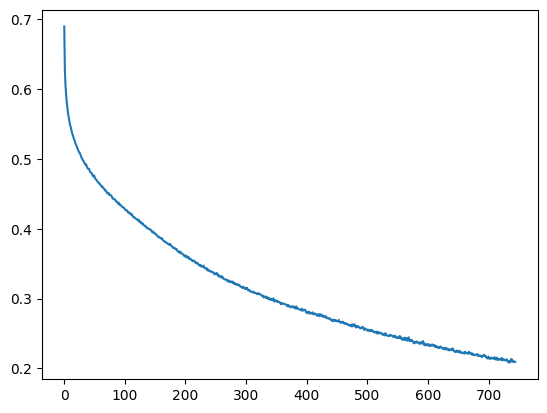

In [ ]:
plt.plot(clf.loss_curve_)
plt.show()

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(128, 64, 32,), alpha=0.1,
                    learning_rate='adaptive',
                    activation='tanh', early_stopping=False,
                    momentum=0.9, random_state=0, max_iter=500)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6804570527974784
F1-score [0.72424345 0.62014052]
              precision    recall  f1-score   support

         0.0       0.75      0.70      0.72      1517
         1.0       0.59      0.65      0.62      1021

    accuracy                           0.68      2538
   macro avg       0.67      0.68      0.67      2538
weighted avg       0.69      0.68      0.68      2538



In [ ]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

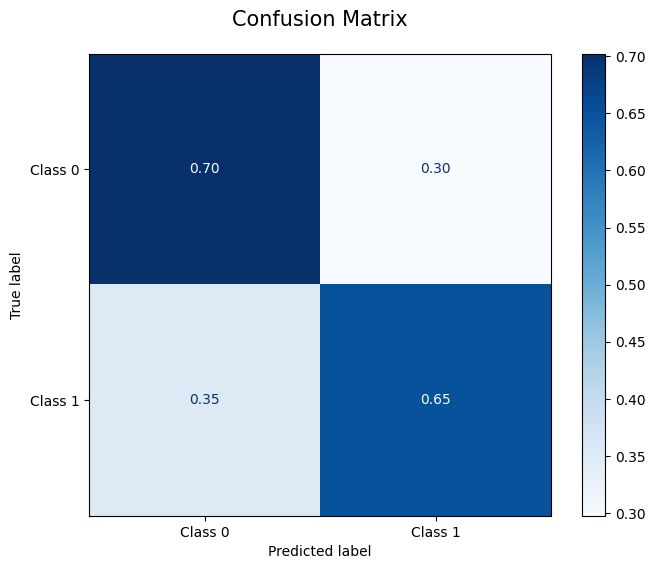

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

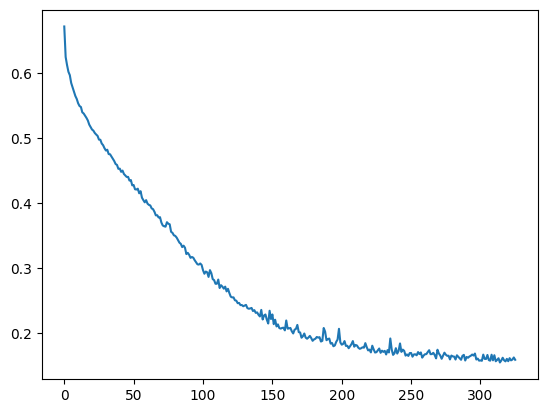

In [ ]:
plt.plot(clf.loss_curve_)
plt.show()

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(128, 64, 32,), alpha=0.1, learning_rate='adaptive',
                    activation='tanh', early_stopping=True, momentum=0.9, random_state=0)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.7304964539007093
F1-score [0.76954178 0.67552182]
              precision    recall  f1-score   support

         0.0       0.79      0.75      0.77      1517
         1.0       0.66      0.70      0.68      1021

    accuracy                           0.73      2538
   macro avg       0.72      0.73      0.72      2538
weighted avg       0.73      0.73      0.73      2538



In [ ]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

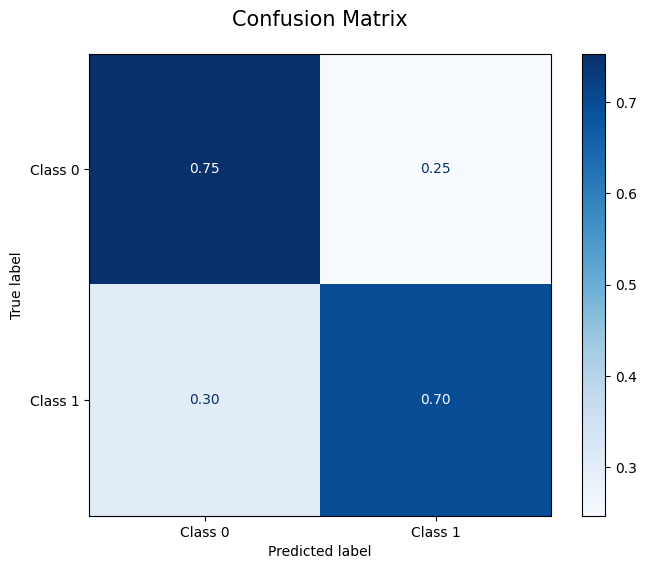

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

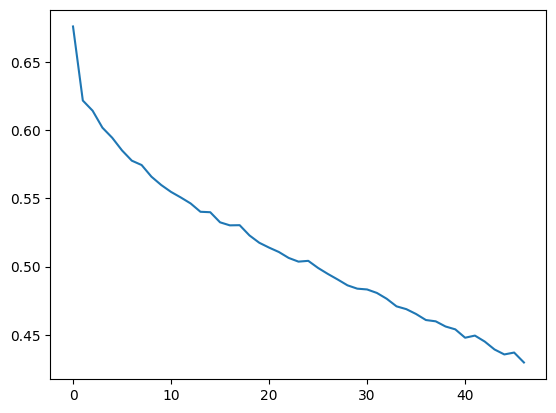

In [ ]:
plt.plot(clf.loss_curve_)
plt.show()

**Basic_Demos-Enroll_Season**

In [ ]:
df['sii']=df_original.loc[df.index, 'sii']
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,...,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii
0,0,5.0,3,51.00,0,46.000,50.8,26.0,73.9,85.6,...,50.55,71.8,0,3,16.877316,6.5,12.3225,2.006,448.0,2
1,2,9.0,1,62.55,0,48.000,46.0,22.0,75.0,70.0,...,46.00,64.0,2,0,14.035590,11.0,20.6250,2.010,334.0,0
2,2,10.0,0,71.00,0,56.500,75.6,25.4,65.0,94.0,...,38.00,54.0,2,2,16.648696,10.0,12.4500,2.009,453.0,0
3,3,9.0,0,71.00,2,56.000,81.6,26.0,60.0,97.0,...,31.00,45.0,3,0,18.292347,7.0,20.6250,2.010,577.0,1
4,1,18.0,2,65.00,1,55.003,77.0,26.0,68.0,77.9,...,41.60,61.4,1,1,17.894545,9.1,21.5525,1.040,460.0,1


In [ ]:
df_NN = df.copy()

In [ ]:
df.drop(columns=['Basic_Demos-Enroll_Season'], inplace=True)

In [ ]:
X = df.values
y = np.array(df_NN['Basic_Demos-Enroll_Season'])

In [ ]:
ctr = Counter(y)
ctr

Counter({1: 2447, 3: 2173, 2: 2002, 0: 1838})

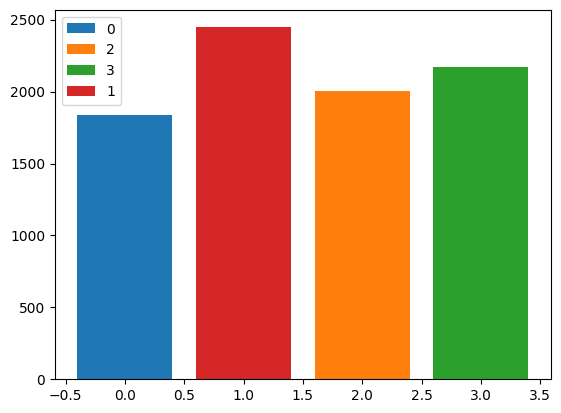

In [ ]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
plt.legend()
plt.show()

In [ ]:
def plot_pca(X_pca, y_train):
    classes = [0.0, 1.0, 2.0, 3.0]
    colors  = ['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e']  # Verde, Rosso, Blu, Arancione

    for cls, color in zip(classes, colors):
        mask = y_train == cls
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=f'Class {int(cls)}',
                    edgecolor='k', alpha=0.7)

    plt.legend()
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA — 2 componenti principali')
    plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 6852 samples
Distribution of classes after SMOTE : {0: 1713, 1: 1713, 2: 1713, 3: 1713}


In [ ]:
# SelectFromModel with XGBoost
sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(6852, 7)

In [ ]:
clf = MLPClassifier(random_state=0, max_iter=1000)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.8187549251379038
F1-score [0.83920076 0.81800132 0.79409209 0.8246515 ]
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       537
           1       0.80      0.84      0.82       734
           2       0.78      0.81      0.79       562
           3       0.85      0.80      0.82       705

    accuracy                           0.82      2538
   macro avg       0.82      0.82      0.82      2538
weighted avg       0.82      0.82      0.82      2538



In [ ]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

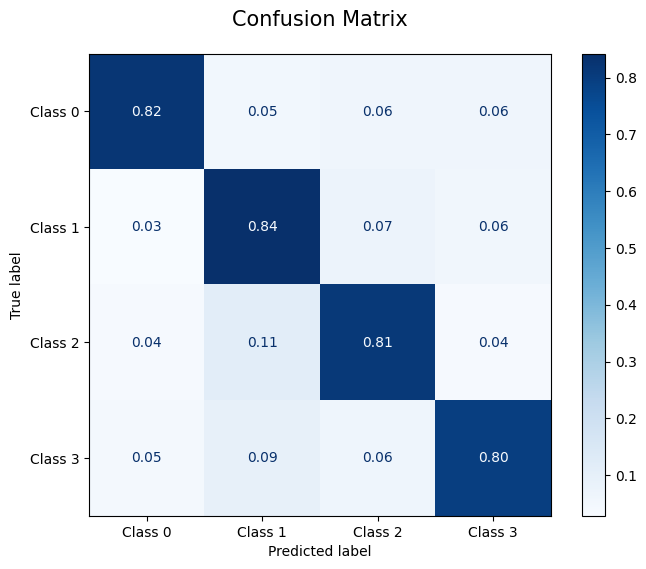

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

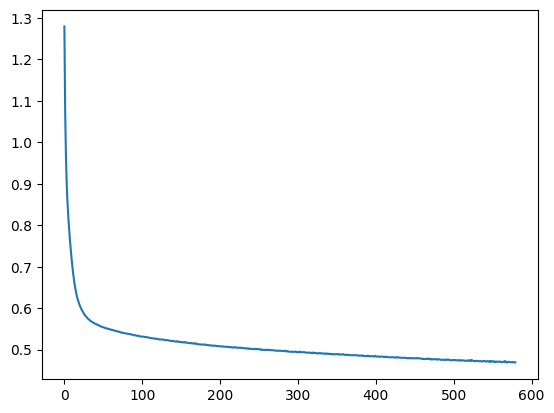

In [ ]:
plt.plot(clf.loss_curve_)
plt.show()

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(128, 64, 32,), alpha=0.1,
                    learning_rate='adaptive',
                    activation='tanh', early_stopping=False,
                    momentum=0.9, random_state=0, max_iter=500)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.8010244286840031
F1-score [0.81578947 0.80529801 0.76923077 0.8110868 ]
              precision    recall  f1-score   support

           0       0.82      0.81      0.82       537
           1       0.78      0.83      0.81       734
           2       0.76      0.77      0.77       562
           3       0.83      0.79      0.81       705

    accuracy                           0.80      2538
   macro avg       0.80      0.80      0.80      2538
weighted avg       0.80      0.80      0.80      2538



In [ ]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

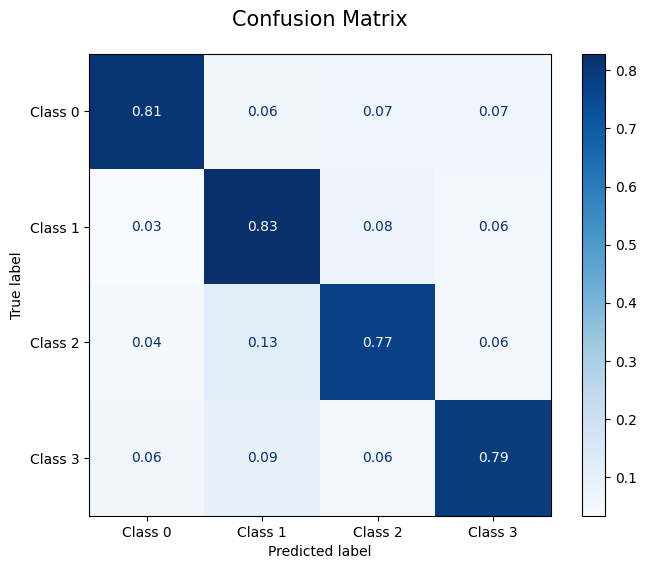

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

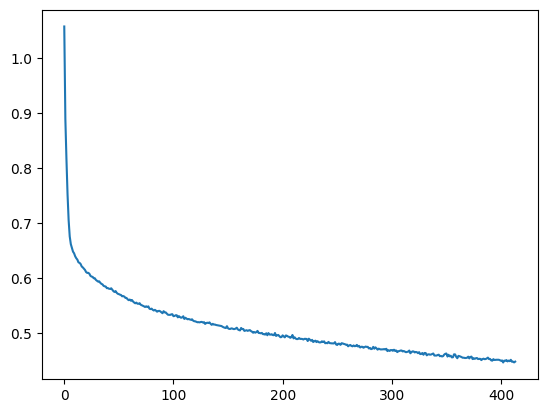

In [ ]:
plt.plot(clf.loss_curve_)
plt.show()

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(128, 64, 32,), alpha=0.1, learning_rate='adaptive',
                    activation='tanh', early_stopping=True, momentum=0.9, random_state=0)

clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.8234830575256107
F1-score [0.83877159 0.81960784 0.80176211 0.83418554]
              precision    recall  f1-score   support

           0       0.87      0.81      0.84       537
           1       0.79      0.85      0.82       734
           2       0.79      0.81      0.80       562
           3       0.86      0.81      0.83       705

    accuracy                           0.82      2538
   macro avg       0.83      0.82      0.82      2538
weighted avg       0.83      0.82      0.82      2538



In [ ]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

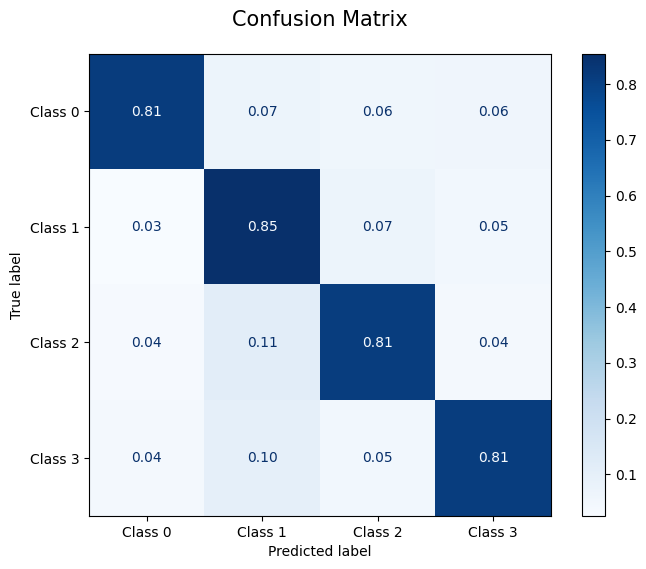

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

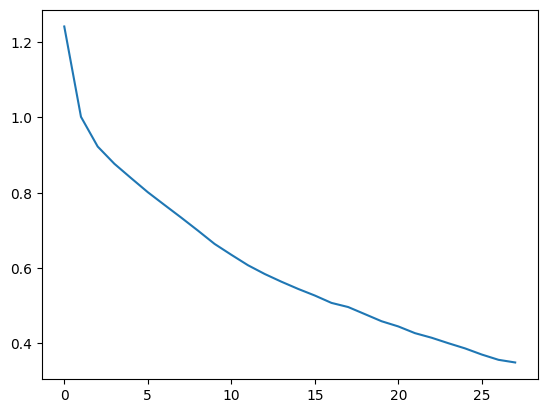

In [ ]:
plt.plot(clf.loss_curve_)
plt.show()

### Keras

In [ ]:
!pip install tensorflow

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [ ]:
from scikeras.wrappers import KerasClassifier

In [ ]:
n_classes = 3
def build_model():
    n_feature = X_train_sel.shape[1]

    model = Sequential()
    model.add(Input(shape=(n_feature,)))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(3, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer="adam", metrics=['accuracy'])
    return model

In [ ]:
model1 = build_model()
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,243 (40.01 KB)

 Trainable params: 10,243 (40.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history1 = model1.fit(X_train_sel, y_train_resampled, epochs=200, batch_size=32).history

Epoch 1/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9207 - loss: 0.2089
Epoch 2/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9683 - loss: 0.0880
Epoch 3/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9735 - loss: 0.0735
Epoch 4/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9776 - loss: 0.0647
Epoch 5/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9779 - loss: 0.0602
Epoch 6/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9771 - loss: 0.0634
Epoch 7/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9809 - loss: 0.0525
Epoch 8/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9797 - loss: 0.0514
Epoch 9/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9819 - loss: 0.0512
Epoch 10/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9822 - loss: 0.0485
Epoch 11/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9831 - loss: 0.0445
Epoch 12/200
423/423 ━━━━━━━━━━━━━━━━━━━━

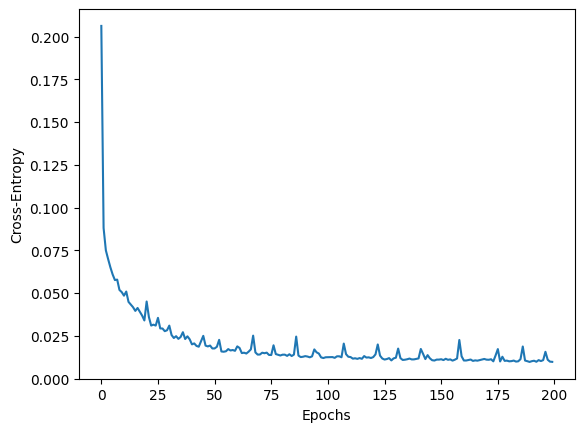

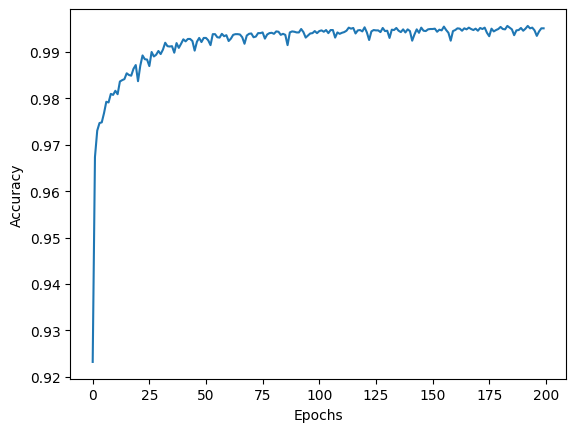

In [ ]:
plt.plot(history1['loss'])
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.show()
plt.plot(history1['accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
test_loss_1, test_acc_1 = model1.evaluate(X_test_sel, y_test)
print('Loss %f, Accuracy %f' % (test_loss_1, test_acc_1))

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9441 - loss: 0.4265
Loss 0.426459, Accuracy 0.944050


### Sklearn Wrapper
wraps a keras model in a sklearn-like object

In [ ]:
!pip install "scikeras>=0.13.0" "scikit-learn>=1.4,<1.6"

In [ ]:
clf = KerasClassifier(build_fn=build_model)

In [ ]:
clf.fit(X_train_sel, y_train_resampled, epochs=200)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


423/423 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9256 - loss: 0.2008
Epoch 2/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9690 - loss: 0.0861
Epoch 3/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9731 - loss: 0.0737
Epoch 4/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9773 - loss: 0.0630
Epoch 5/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9788 - loss: 0.0587
Epoch 6/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9799 - loss: 0.0530
Epoch 7/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9804 - loss: 0.0526
Epoch 8/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9808 - loss: 0.0523
Epoch 9/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9820 - loss: 0.0469
Epoch 10/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9805 - loss: 0.0492
Epoch 11/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9839 - loss: 0.0443
Epoch 12/200
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

KerasClassifier(
	model=None
	build_fn=<function build_model at 0x7a6fc1fc9760>
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

In [ ]:
clf.model_.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,731 (120.05 KB)

 Trainable params: 10,243 (40.01 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,488 (80.04 KB)

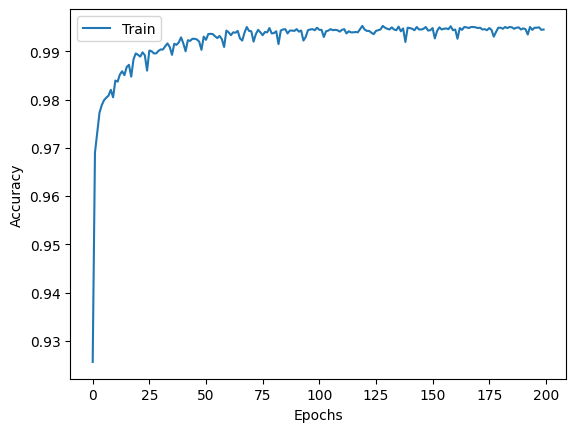

In [ ]:
history = clf.history_
plt.plot(history['accuracy'], label='Train')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

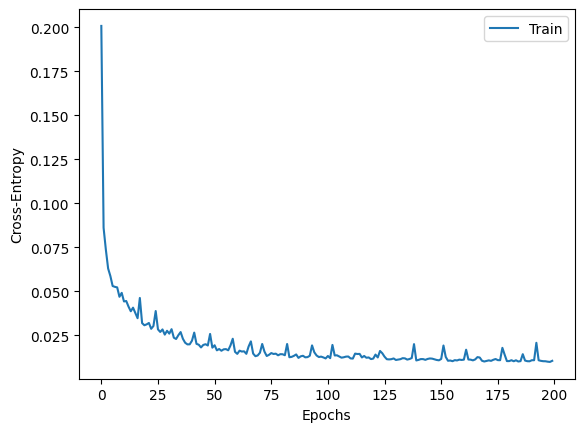

In [ ]:
plt.plot(history['loss'], label='Train')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

In [ ]:
y_pred = clf.predict(X_test_sel).astype(int)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy 0.9405043341213554
F1-score [0.96920747 0.83497268 0.85427136]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1980
           1       0.83      0.84      0.83       453
           2       0.90      0.81      0.85       105

    accuracy                           0.94      2538
   macro avg       0.90      0.87      0.89      2538
weighted avg       0.94      0.94      0.94      2538



In [ ]:
clf = KerasClassifier(build_fn=build_model)

In [ ]:
clf.fit(X_train_sel, y_train_resampled, validation_split=0.2, epochs=1000)

Epoch 1/1000


/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9151 - loss: 0.2488 - val_accuracy: 0.9563 - val_loss: 0.1264
Epoch 2/1000
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9617 - loss: 0.1062 - val_accuracy: 0.9963 - val_loss: 0.0184
Epoch 3/1000
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9660 - loss: 0.0908 - val_accuracy: 0.9893 - val_loss: 0.0368
Epoch 4/1000
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9707 - loss: 0.0807 - val_accuracy: 0.9974 - val_loss: 0.0096
Epoch 5/1000
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9705 - loss: 0.0788 - val_accuracy: 0.9982 - val_loss: 0.0072
Epoch 6/1000
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9736 - loss: 0.0715 - val_accuracy: 0.9822 - val_loss: 0.0688
Epoch 7/1000
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9726 - loss: 0.0717 - val_accuracy: 0.9882 - val_loss: 0.0329
Epoch 8/1000
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9745 - loss: 0.0670 - val_accuracy:

KerasClassifier(
	model=None
	build_fn=<function build_model at 0x7a6fc1fc9760>
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

In [37]:
y_pred = clf.predict(X_test_sel).astype(int)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Accuracy 0.9373522458628841
F1-score [0.96762682 0.83350785 0.83838384]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1980
           1       0.79      0.88      0.83       453
           2       0.89      0.79      0.84       105

    accuracy                           0.94      2538
   macro avg       0.89      0.88      0.88      2538
weighted avg       0.94      0.94      0.94      2538



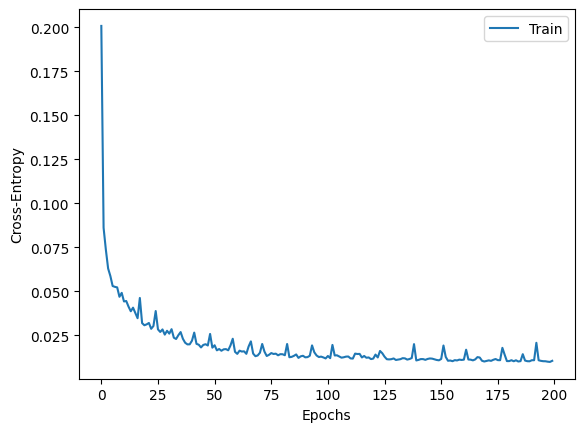

In [40]:
plt.plot(history['loss'], label='Train')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

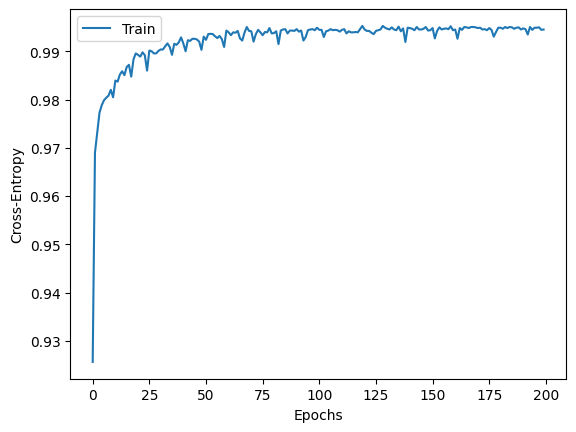

In [41]:
plt.plot(history['accuracy'], label='Train')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

### Early stopping

In [42]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [43]:
es = EarlyStopping(monitor='val_accuracy', patience=50, verbose=True)
mc = ModelCheckpoint('best_model_NOREG.keras', monitor='val_accuracy', save_best_only=True)

clf = KerasClassifier(build_model, callbacks=[es, mc])

In [44]:
clf.fit(X_train_sel, y_train_resampled, validation_split=0.2, epochs=500)

Epoch 1/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9163 - loss: 0.2551 - val_accuracy: 0.9649 - val_loss: 0.1065
Epoch 2/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9636 - loss: 0.1034 - val_accuracy: 0.9882 - val_loss: 0.0545
Epoch 3/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9660 - loss: 0.0928 - val_accuracy: 0.9874 - val_loss: 0.0452
Epoch 4/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9690 - loss: 0.0827 - val_accuracy: 0.9945 - val_loss: 0.0178
Epoch 5/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9710 - loss: 0.0765 - val_accuracy: 0.9863 - val_loss: 0.0543
Epoch 6/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9737 - loss: 0.0718 - val_accuracy: 0.9830 - val_loss: 0.0542
Epoch 7/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9735 - loss: 0.0682 - val_accuracy: 0.9889 - val_loss: 0.0457
Epoch 8/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9757 - loss: 0.0651 - val_accu

KerasClassifier(
	model=<function build_model at 0x7a6fc1fc9760>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x7a6f9b402450>, <keras.src.callbacks.model_checkpoint.ModelCheckpoint object at 0x7a6f9b403560>]
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

In [45]:
y_pred = clf.predict(X_test_sel).astype(int)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy 0.9385342789598109
F1-score [0.9682338  0.83404255 0.84577114]
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1980
           1       0.80      0.87      0.83       453
           2       0.89      0.81      0.85       105

    accuracy                           0.94      2538
   macro avg       0.89      0.88      0.88      2538
weighted avg       0.94      0.94      0.94      2538



In [46]:
y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy 0.9385342789598109
F1-score [0.9682338  0.83404255 0.84577114]
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1980
           1       0.80      0.87      0.83       453
           2       0.89      0.81      0.85       105

    accuracy                           0.94      2538
   macro avg       0.89      0.88      0.88      2538
weighted avg       0.94      0.94      0.94      2538



### L2 Regularization

In [48]:
from keras.regularizers import l2, l1

def build_L2_model():
    model = Sequential()

    n_feature = X_train_sel.shape[1]
    h_dim=100
    model.add(Dense(h_dim, activation='relu',
                    input_shape=(n_feature,), kernel_regularizer=l2(0.001)))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dense(n_classes))

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

In [50]:
mc = ModelCheckpoint('best_model_L2.keras', monitor='val_accuracy', save_best_only=True)

L2_model = KerasClassifier(build_L2_model, callbacks=[es,mc])
L2_model.fit(X_train_sel, y_train_resampled, validation_split=0.2, epochs=500)

Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


338/338 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6065 - loss: 1.0431 - val_accuracy: 0.1517 - val_loss: 1.1201
Epoch 2/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5324 - loss: 0.8955 - val_accuracy: 0.9245 - val_loss: 1.1187
Epoch 3/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5152 - loss: 0.9199 - val_accuracy: 0.9286 - val_loss: 1.1170
Epoch 4/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5145 - loss: 0.9167 - val_accuracy: 0.9323 - val_loss: 1.1150
Epoch 5/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5364 - loss: 0.9092 - val_accuracy: 0.8986 - val_loss: 1.1131
Epoch 6/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6410 - loss: 0.8168 - val_accuracy: 0.7714 - val_loss: 1.1111
Epoch 7/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4940 - loss: 1.0334 - val_accuracy: 0.5609 - val_loss: 1.1096
Epoch 8/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4584 - loss: 1.0731 - val_accuracy: 0.5583

KerasClassifier(
	model=<function build_L2_model at 0x7a6f9b23e980>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x7a6f9b402450>, <keras.src.callbacks.model_checkpoint.ModelCheckpoint object at 0x7a6f9b455eb0>]
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

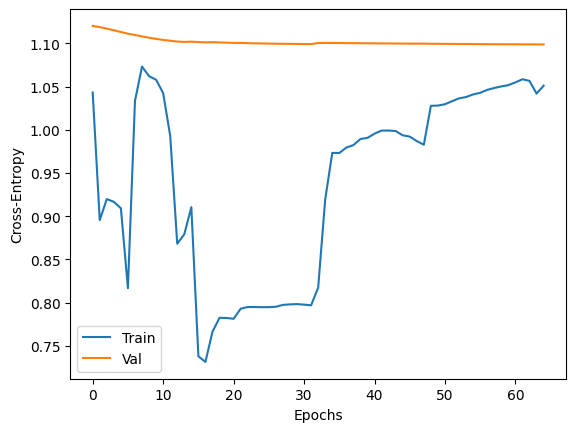

In [51]:
history = L2_model.history_
plt.plot(history['loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

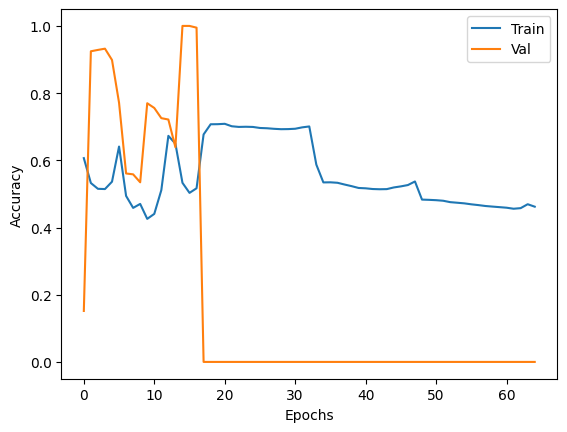

In [52]:
plt.plot(history['accuracy'], label='Train')
plt.plot(history['val_accuracy'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### Dropout

In [55]:
from keras.layers import Dropout

def build_DROPOUT_model(meta):
    # define the model
    model = Sequential()

    n_feature = meta["n_features_in_"]
    n_classes = meta["n_classes_"]
    h_dim = 100
    model.add(Dense(h_dim, activation='relu', input_shape=(n_feature,)))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(h_dim, activation='relu'))
    #linear activation
    model.add(Dense(n_classes, activation='softmax')) # Added activation for multiclass

    #compile the model
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

mc = ModelCheckpoint('best_model_DROPOUT.keras', monitor='val_accuracy', save_best_only=True)

DROPOUT_model = KerasClassifier(build_DROPOUT_model, callbacks=[es,mc])
DROPOUT_model.fit(X_train_sel, y_train_resampled, validation_split=0.2, epochs=500)

Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


338/338 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9210 - loss: 0.2126 - val_accuracy: 0.8276 - val_loss: 0.4344
Epoch 2/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9601 - loss: 0.1078 - val_accuracy: 0.9896 - val_loss: 0.0388
Epoch 3/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9671 - loss: 0.0914 - val_accuracy: 0.9993 - val_loss: 0.0095
Epoch 4/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9709 - loss: 0.0792 - val_accuracy: 0.9993 - val_loss: 0.0020
Epoch 5/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9732 - loss: 0.0723 - val_accuracy: 0.9967 - val_loss: 0.0125
Epoch 6/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9761 - loss: 0.0643 - val_accuracy: 0.9896 - val_loss: 0.0361
Epoch 7/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9779 - loss: 0.0620 - val_accuracy: 0.9919 - val_loss: 0.0255
Epoch 8/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9792 - loss: 0.0566 - val_accuracy: 0.9985

KerasClassifier(
	model=<function build_DROPOUT_model at 0x7a6f9b035120>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x7a6f9b402450>, <keras.src.callbacks.model_checkpoint.ModelCheckpoint object at 0x7a6f9a92cf20>]
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

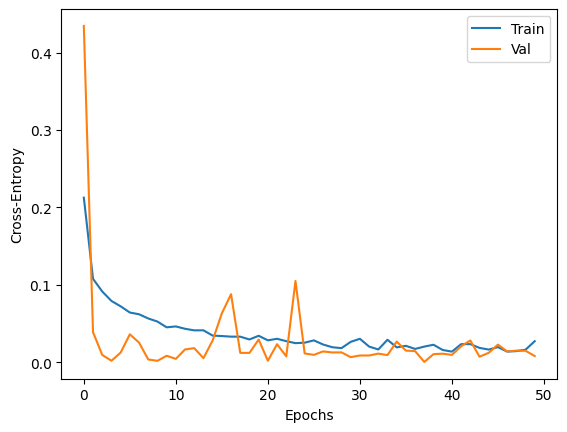

In [56]:
history = DROPOUT_model.history_
plt.plot(history['loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

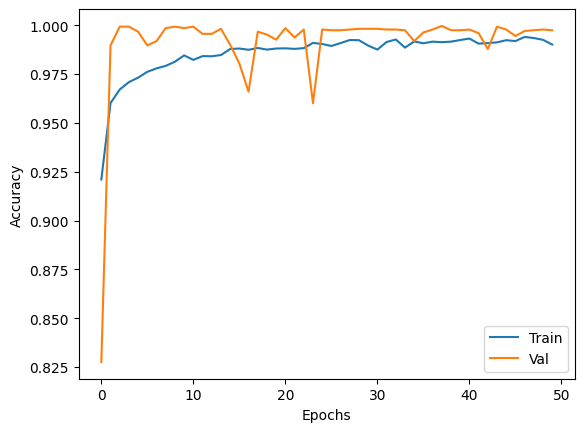

In [57]:
plt.plot(history['accuracy'], label='Train')
plt.plot(history['val_accuracy'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### Model Comparison

In [61]:
# laod best models and test them
from keras.models import load_model

best_NOREG_model = load_model('best_model_NOREG.keras')
best_L2_model = load_model('best_model_L2.keras')
best_DROPOUT_model = load_model('best_model_DROPOUT.keras')

loss_NOREG, acc_NOREG = best_NOREG_model.evaluate(X_test_sel, y_test)
loss_L2, acc_L2 = best_L2_model.evaluate(X_test_sel, y_test)
loss_DROPOUT, acc_DROPOUT = best_DROPOUT_model.evaluate(X_test_sel, y_test)

80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9441 - loss: 0.1773
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6757 - loss: 0.4140
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9374 - loss: 0.4060


In [62]:
print('Loss %f, Accuracy %f' % (loss_NOREG, acc_NOREG))
print('Loss %f, Accuracy %f' % (loss_L2, acc_L2))
print('Loss %f, Accuracy %f' % (loss_DROPOUT, acc_DROPOUT))

Loss 0.177310, Accuracy 0.944050
Loss 0.414038, Accuracy 0.675729
Loss 0.405965, Accuracy 0.937352


#### Hyper-Parameter Tuning

In [63]:
from sklearn.model_selection import RandomizedSearchCV

In [64]:
def build_model(meta, hidden_layer_sizes, activation):
    n_features_in_ = meta["n_features_in_"]
    n_classes_ = meta["n_classes_"]
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(n_features_in_,)))
    for hidden_layer_size in hidden_layer_sizes:
        model.add(keras.layers.Dense(hidden_layer_size, activation=activation))
    model.add(keras.layers.Dense(n_classes_, activation="softmax"))
    return model

In [65]:
clf = KerasClassifier(
    model=build_model,
    loss="sparse_categorical_crossentropy",
    verbose=False
)

In [66]:
params = {
    'optimizer__learning_rate': [0.001, 0.01, 0.1, 1],
    'model__hidden_layer_sizes': [(100, 100, 100), (50, 50, 50), (10, 10, 10),
                                  (100, 50, 10), (10, 10, 10), (10, 10)],
    'model__activation': ['relu', 'tanh'],
    'optimizer': ["adam", "sgd"],
    'epochs': [10, 50, 100, 200]
}

gs = RandomizedSearchCV(clf, params, scoring='accuracy', verbose=True, n_iter=15, cv=3)

In [67]:
from tensorflow import keras

In [68]:
gs.fit(X_train_sel, y_train_resampled)

print(gs.best_score_, gs.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
15 fits failed out of a total of 45.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py", line 1501, in fit
    super().fit(X=X, y=y, sample_weight=sample_weight, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py", line 770, in fit
    self._fit(
  File "/usr/local/lib/python3.12/dist-packages/scikeras/wr

0.9774274718768501 {'optimizer__learning_rate': 0.1, 'optimizer': 'sgd', 'model__hidden_layer_sizes': (50, 50, 50), 'model__activation': 'relu', 'epochs': 50}


In [69]:
y_pred = gs.predict(X_test_sel).astype(int)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9377462568951931
F1-score [0.96757723 0.83575884 0.84263959]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1980
           1       0.79      0.89      0.84       453
           2       0.90      0.79      0.84       105

    accuracy                           0.94      2538
   macro avg       0.89      0.88      0.88      2538
weighted avg       0.94      0.94      0.94      2538



In [ ]:
y_score = gs.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

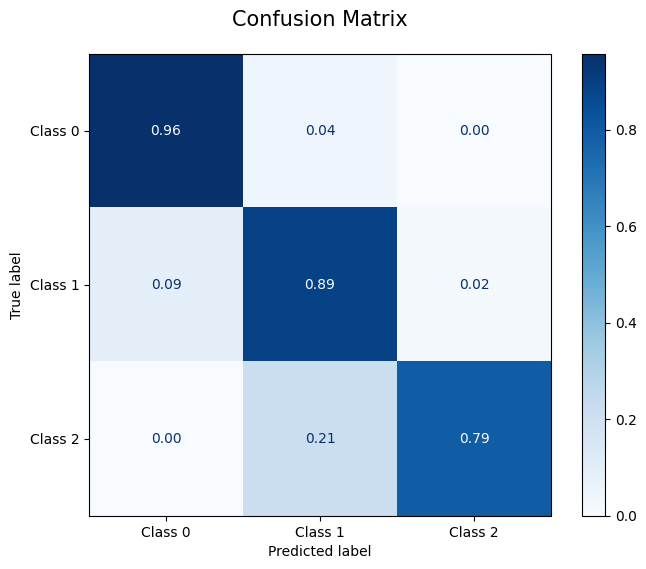

In [71]:
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1", "Class 2"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true',
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()